# Classification — Diabetes Risk Prediction

## Machine Learning Capstone Project

This notebook presents the complete classification workflow for the Diabetes Risk Prediction dataset.

The workflow covers:

- Dataset loading and initial audit
- Exploratory Data Analysis (EDA)
- Data cleaning
- Encoding and feature scaling
- Train-test splitting
- Feature engineering
- Classification model implementation
- Model evaluation
- Preliminary model comparison

The analysis is structured according to the Review 1 requirements of the ML-301 Machine Learning Capstone.

# A. Dataset & EDA

## A1. Dataset Loading and Audit

Before performing any preprocessing or model training, the dataset is loaded and examined to understand its structure, feature types, missing values, duplicate records, and target variable.

The dataset audit is performed before cleaning so that the original data-quality issues can be clearly identified and documented.

In [18]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [19]:
# Load dataset

DATA_PATH = r"C:\Users\HP\Documents\ML-301\data\diabetes_risk_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)

TARGET = "Diabetes_Risk"

# Dataset shape
print("========== DATASET SHAPE ==========")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

# Data types
print("\n========== DATA TYPES ==========")
display(df.dtypes.to_frame("Data Type"))

# Missing values
print("\n========== MISSING VALUES ==========")

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(missing)

# Target distribution
print("\n========== TARGET DISTRIBUTION ==========")
print("Target Variable:", TARGET)

display(
    df[TARGET]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print("\nTarget Distribution (%):")

display(
    (
        df[TARGET]
        .value_counts(normalize=True, dropna=False) * 100
    )
    .round(2)
    .to_frame("Percentage")
)

========== DATASET SHAPE ==========
Rows    : 50000
Columns : 42

========== DATA TYPES ==========


,Data Type
Patient_ID,int64
Age,float64
Gender,str
Country,str
Height_cm,float64
Weight_kg,float64
BMI,float64
Waist_Circumference_cm,float64
Blood_Glucose,float64
HbA1c,float64



========== MISSING VALUES ==========


,Missing Count,Missing Percentage
Patient_ID,0,0.00
Age,497,0.99
Gender,0,0.00
Country,0,0.00
Height_cm,2945,5.89
Weight_kg,2962,5.92
BMI,0,0.00
Waist_Circumference_cm,0,0.00
Blood_Glucose,959,1.92
HbA1c,1974,3.95



========== TARGET DISTRIBUTION ==========
Target Variable: Diabetes_Risk


,Count
Diabetes_Risk,
High,36593
Moderate,12937
Low,470



Target Distribution (%):


,Percentage
Diabetes_Risk,
High,73.19
Moderate,25.87
Low,0.94


## A2. Exploratory Data Analysis

The dataset is explored using target distribution, feature distributions, correlation analysis, and feature-target relationships to identify important patterns and characteristics in the data.

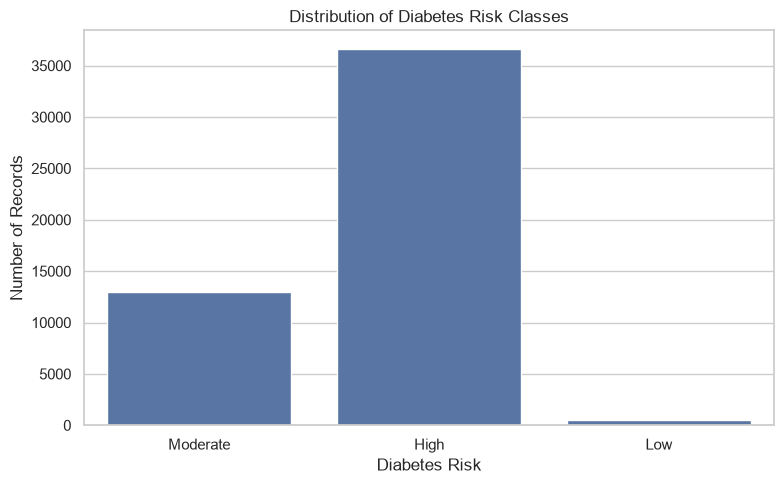

In [20]:
# Target distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Distribution of Diabetes Risk Classes")
plt.xlabel("Diabetes Risk")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### Observation

The target variable `Diabetes_Risk` is highly imbalanced across the three classes. The `High` risk class contains the largest number of records, followed by the `Moderate` class, while the `Low` risk class has comparatively very few observations. This class imbalance should be considered when evaluating the classification models, particularly when comparing accuracy with weighted F1-score.

Number of numerical features: 21


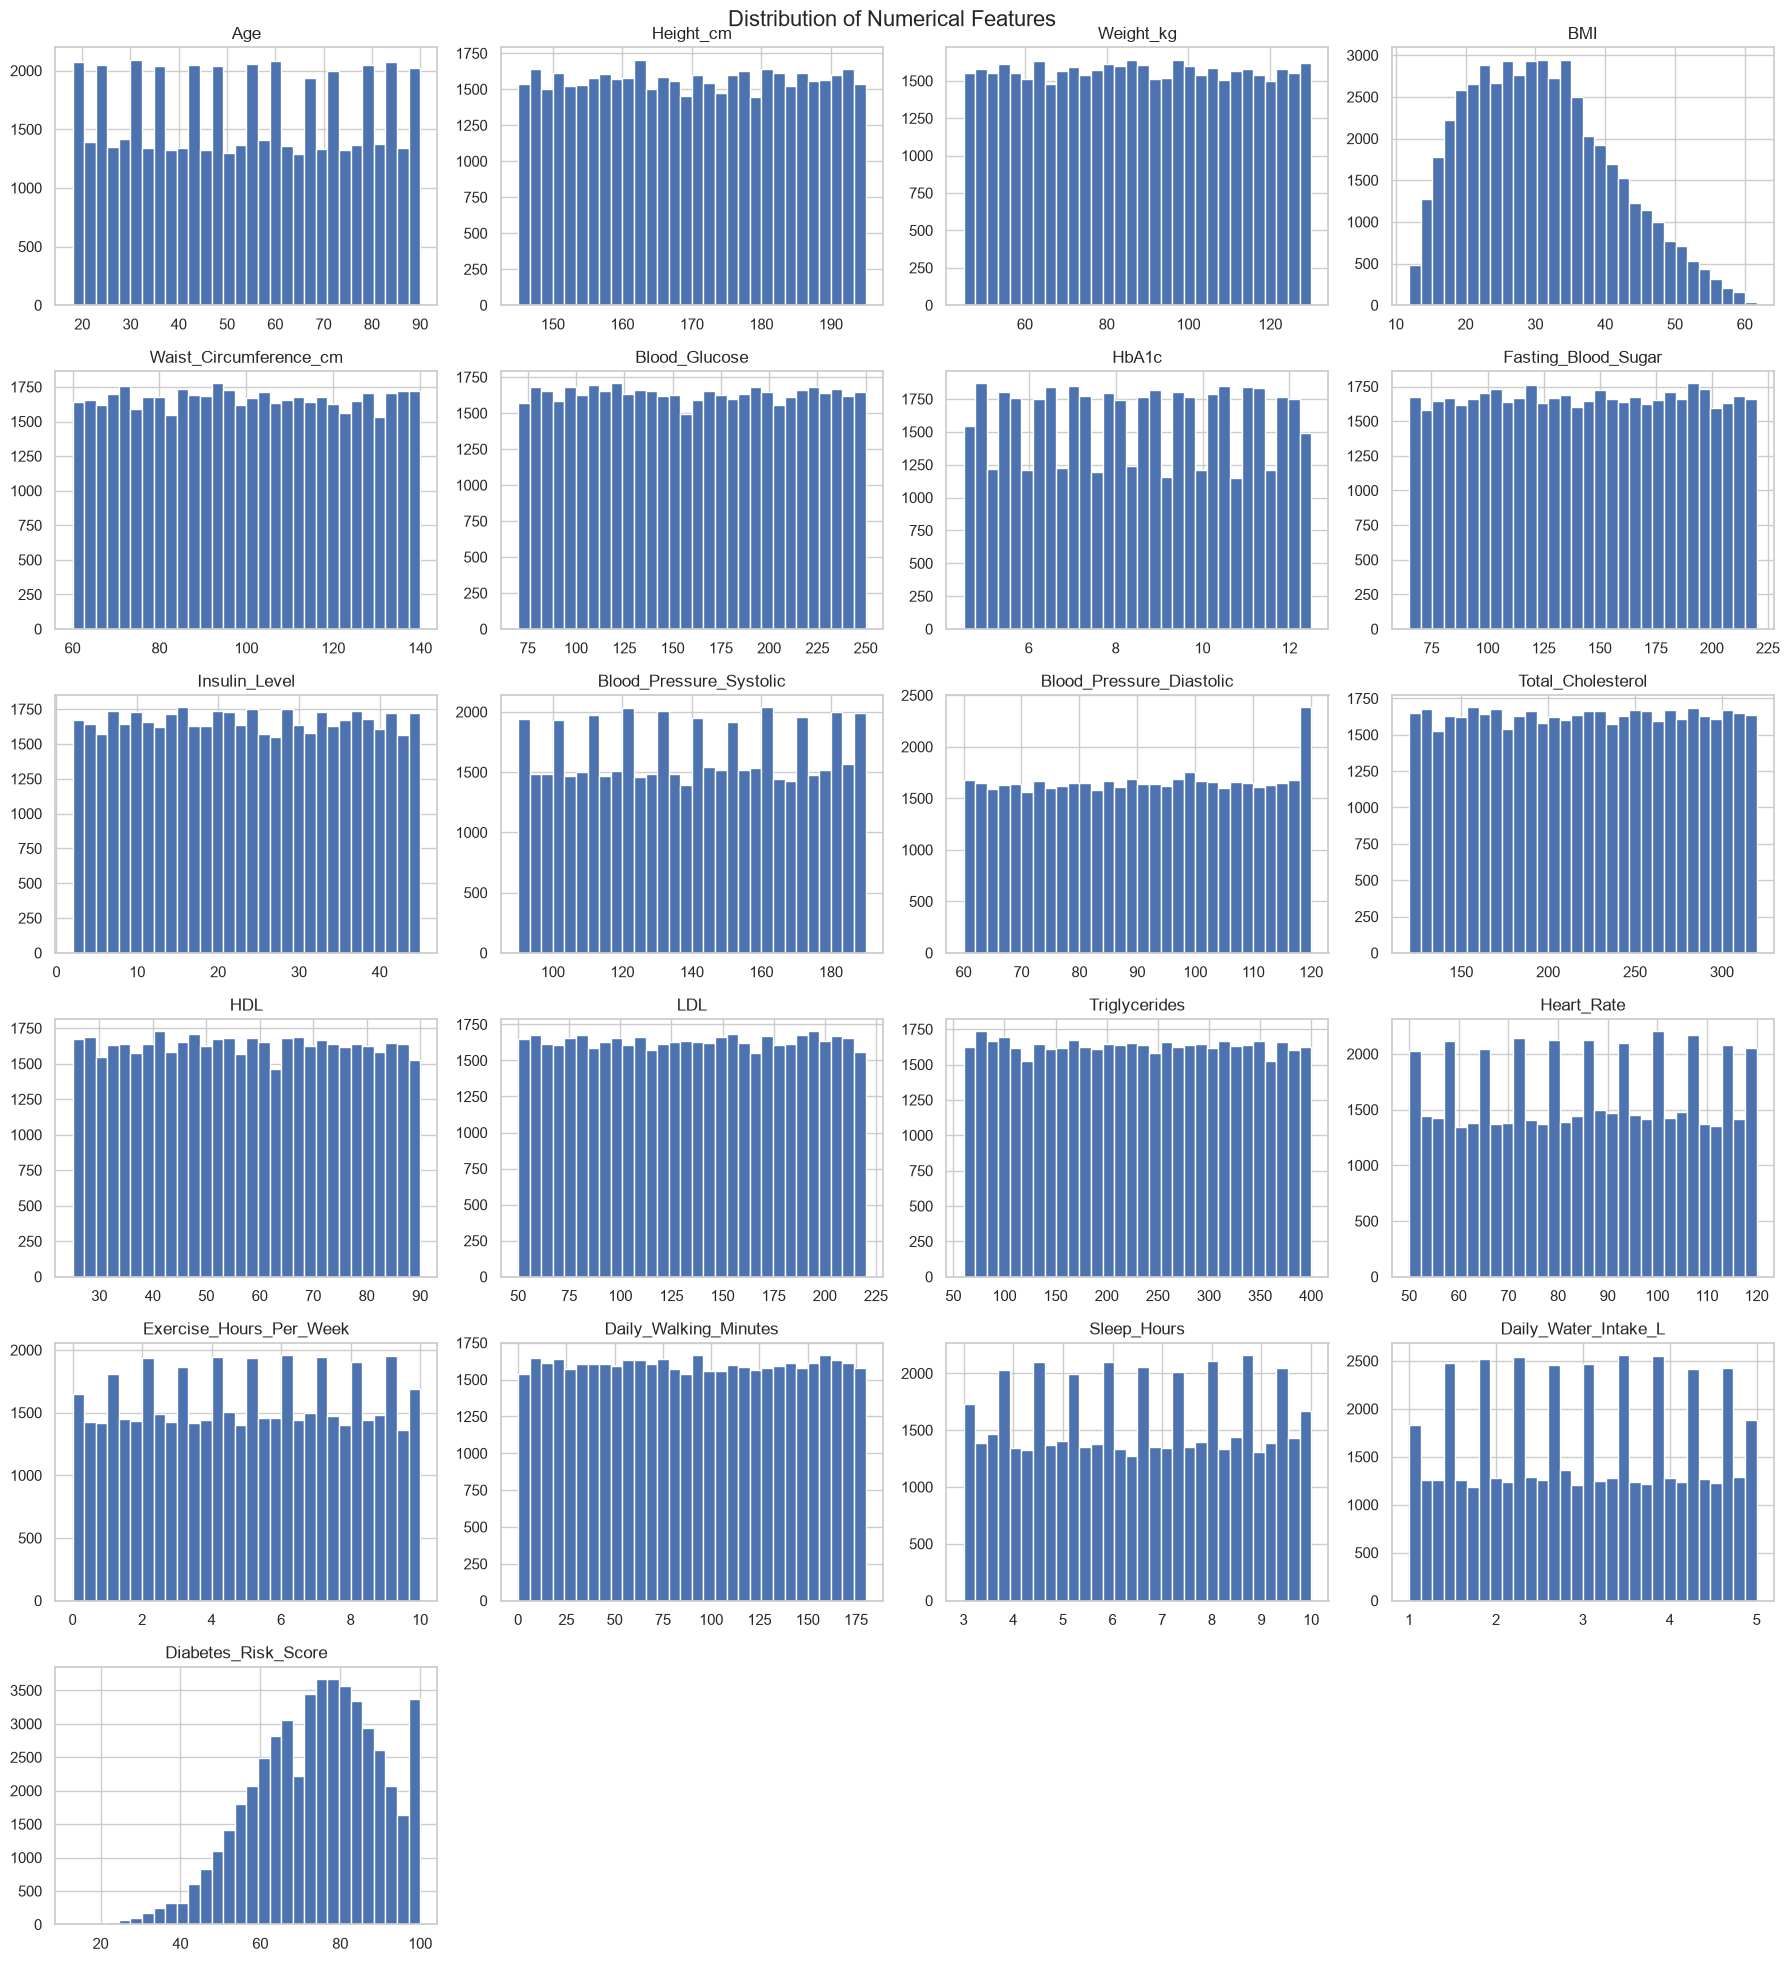

In [21]:
# Numerical feature distributions

numerical_features = df.select_dtypes(
    include=np.number
).columns.tolist()

# Exclude ID and target
numerical_features = [
    col for col in numerical_features
    if col not in ["Patient_ID", TARGET]
]

print("Number of numerical features:", len(numerical_features))

df[numerical_features].hist(
    bins=30,
    figsize=(18, 20),
    layout=(-1, 4)
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

### A3. Numerical Feature Distribution — Observation

The dataset contains 21 numerical features with varied distribution patterns. Most features are broadly distributed across their ranges, while `BMI` shows a noticeable right-skew and `Diabetes_Risk_Score` is more concentrated toward higher values; several other features show repeated peaks across their ranges.

## A2. Categorical Feature Distributions

Categorical features are analysed using count plots to understand the frequency of their different categories and identify dominant or less frequent groups.

C:\Users\HP\AppData\Local\Temp\ipykernel_21824\2193812261.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


Number of categorical features: 19


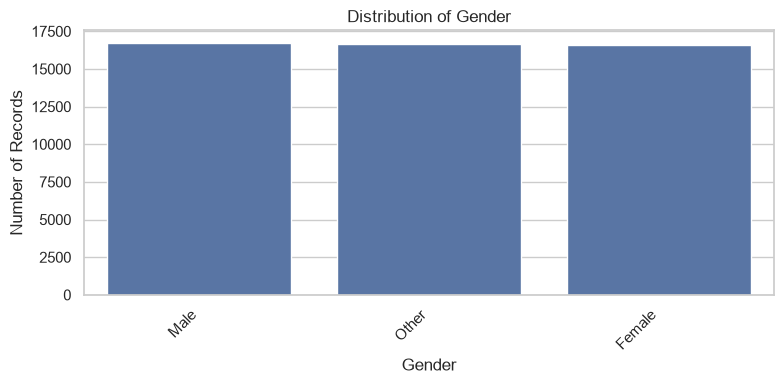

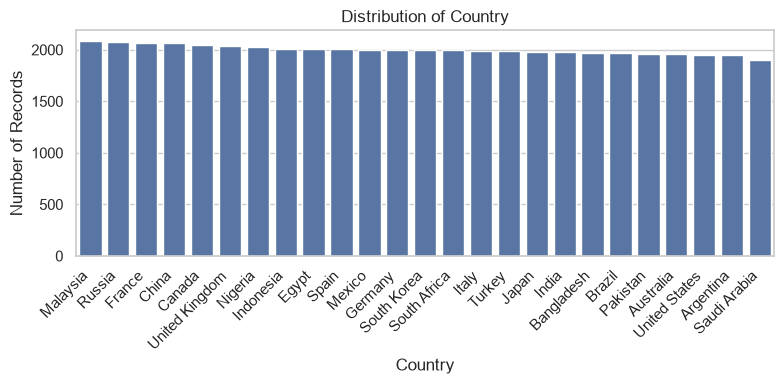

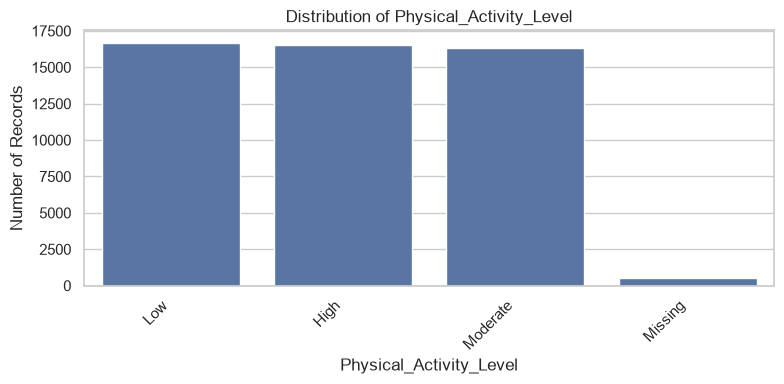

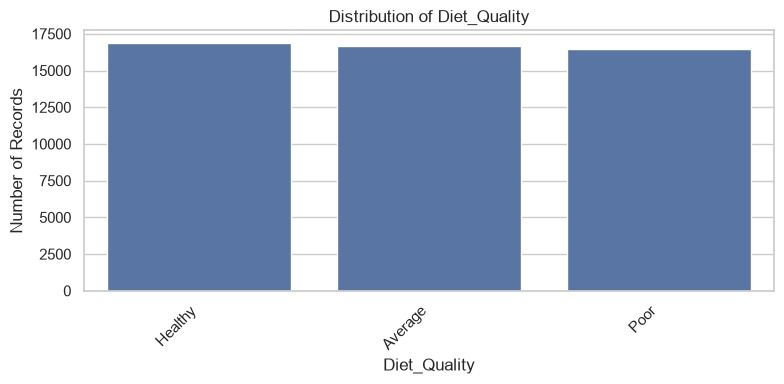

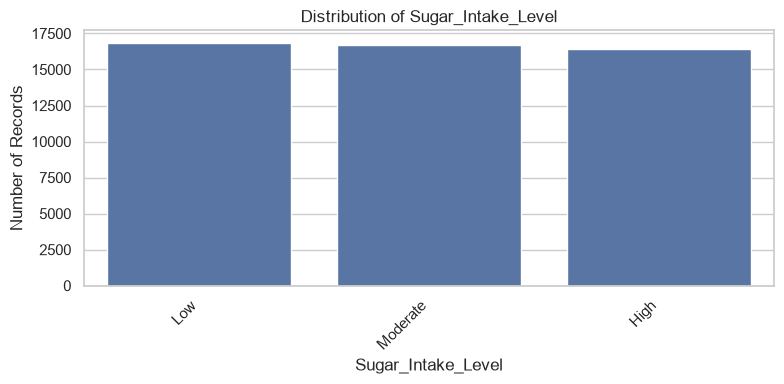

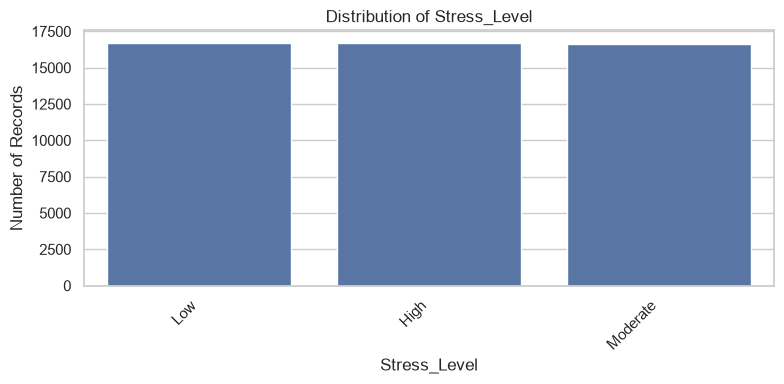

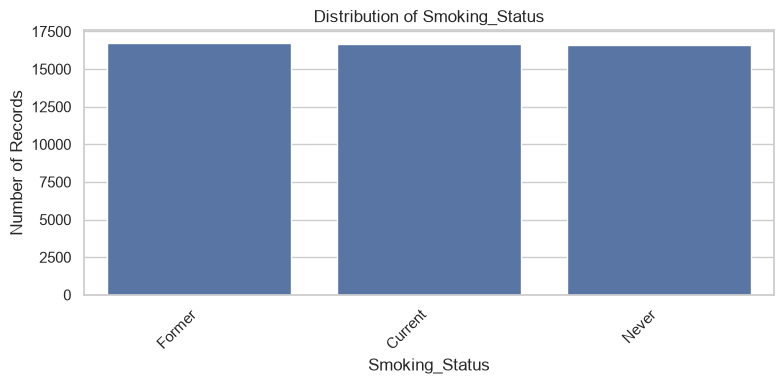

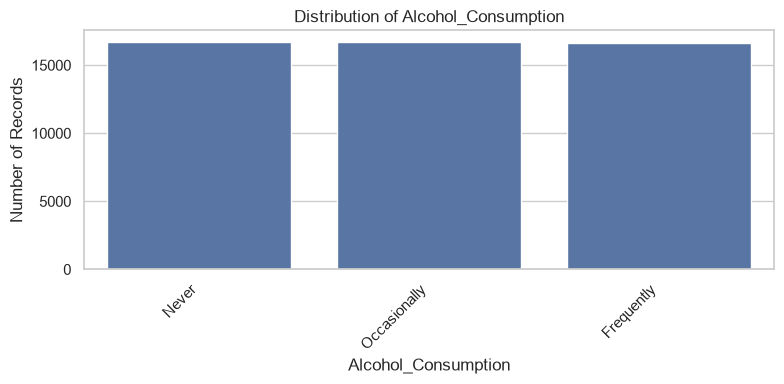

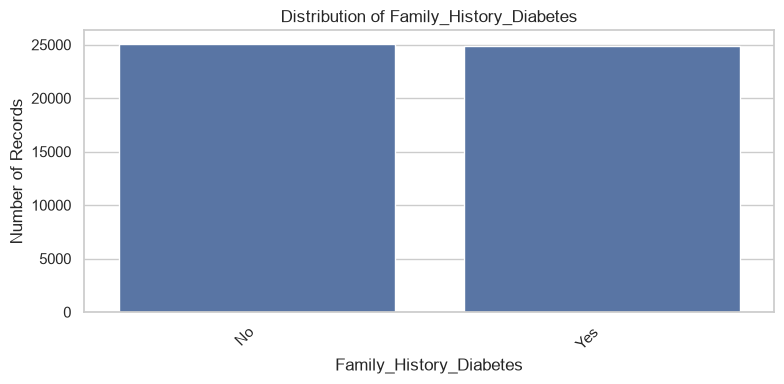

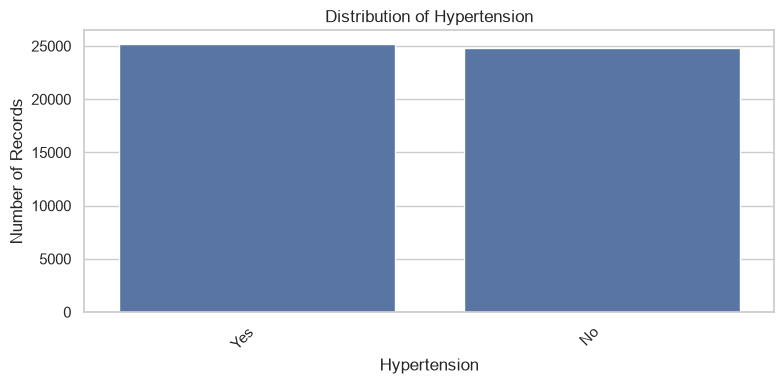

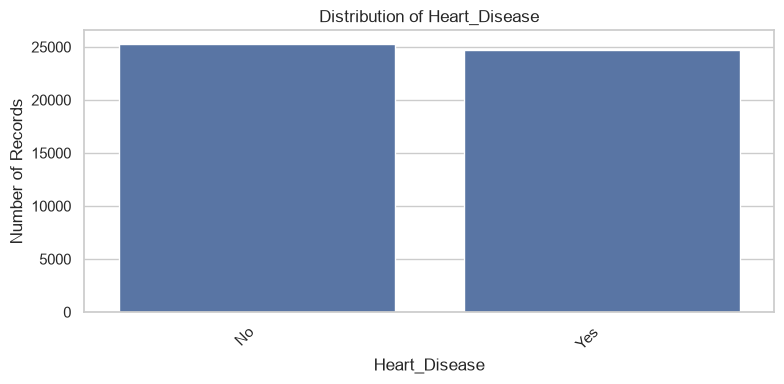

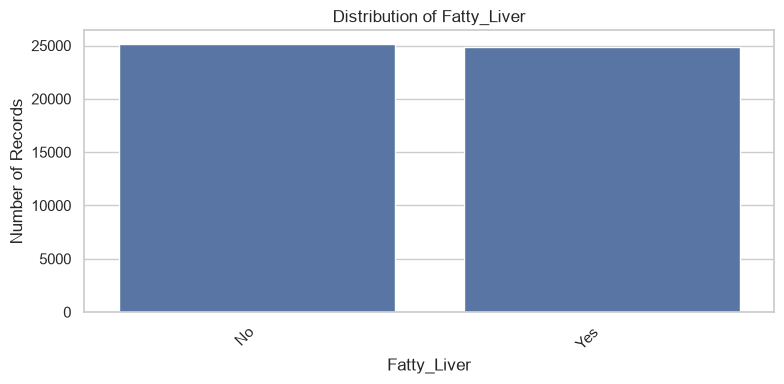

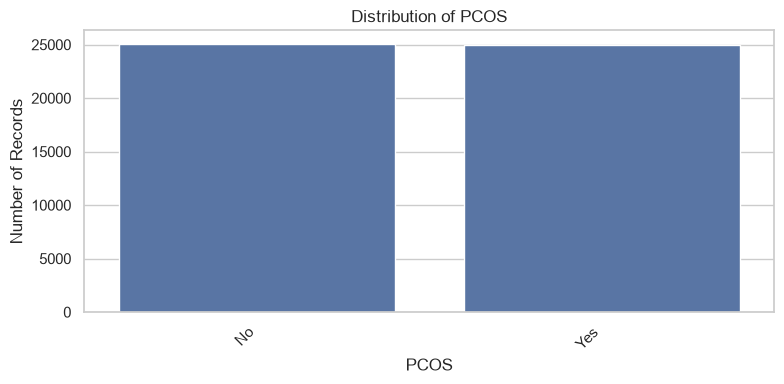

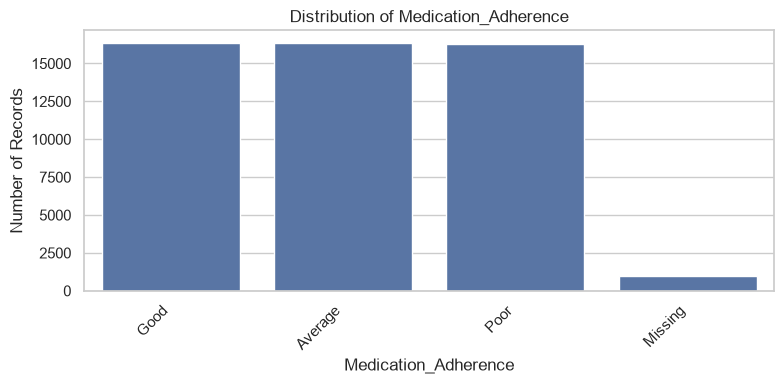

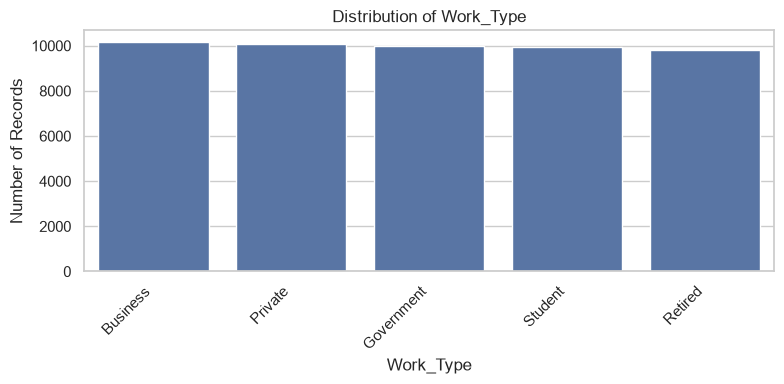

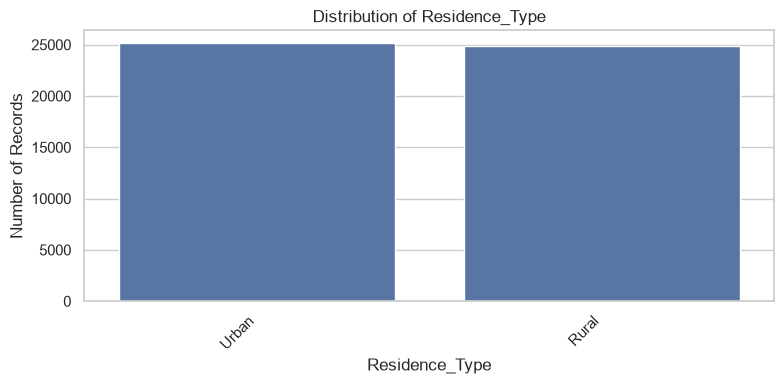

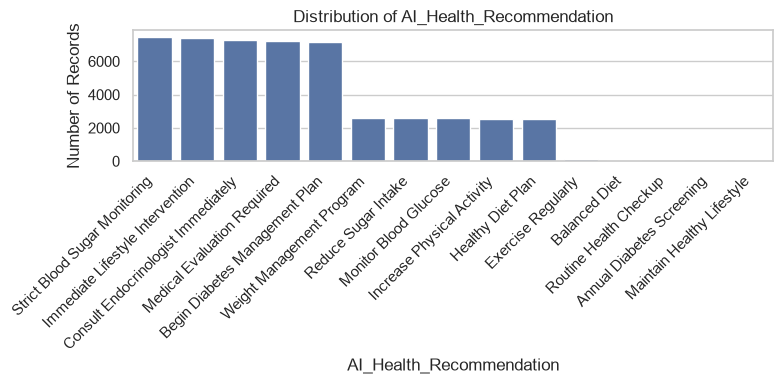

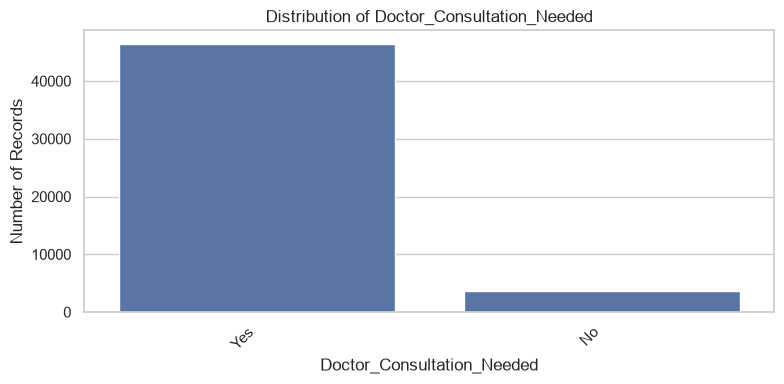

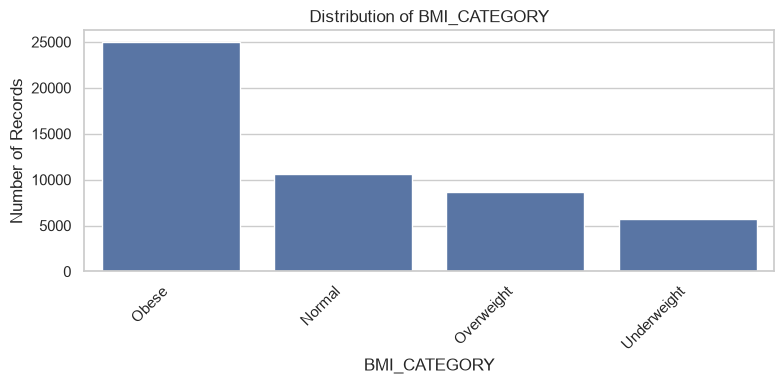

In [22]:
# Categorical feature distributions

categorical_features = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Remove target variable
categorical_features = [
    col for col in categorical_features
    if col != TARGET
]

print("Number of categorical features:", len(categorical_features))

for feature in categorical_features:

    plot_data = df[feature].astype("string").fillna("Missing")

    plt.figure(figsize=(8, 4))

    sns.countplot(
        x=plot_data,
        order=plot_data.value_counts().index
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

### A3. Categorical Feature Distribution — Observation

The categorical features show different category frequencies across the dataset. Most variables have reasonably distributed categories, while a few features show noticeable dominance of certain categories and some missing values. These differences will be considered during categorical encoding and preprocessing.

## A2. Correlation Heatmap

The correlation heatmap is used to examine the relationships among the numerical features in the dataset.

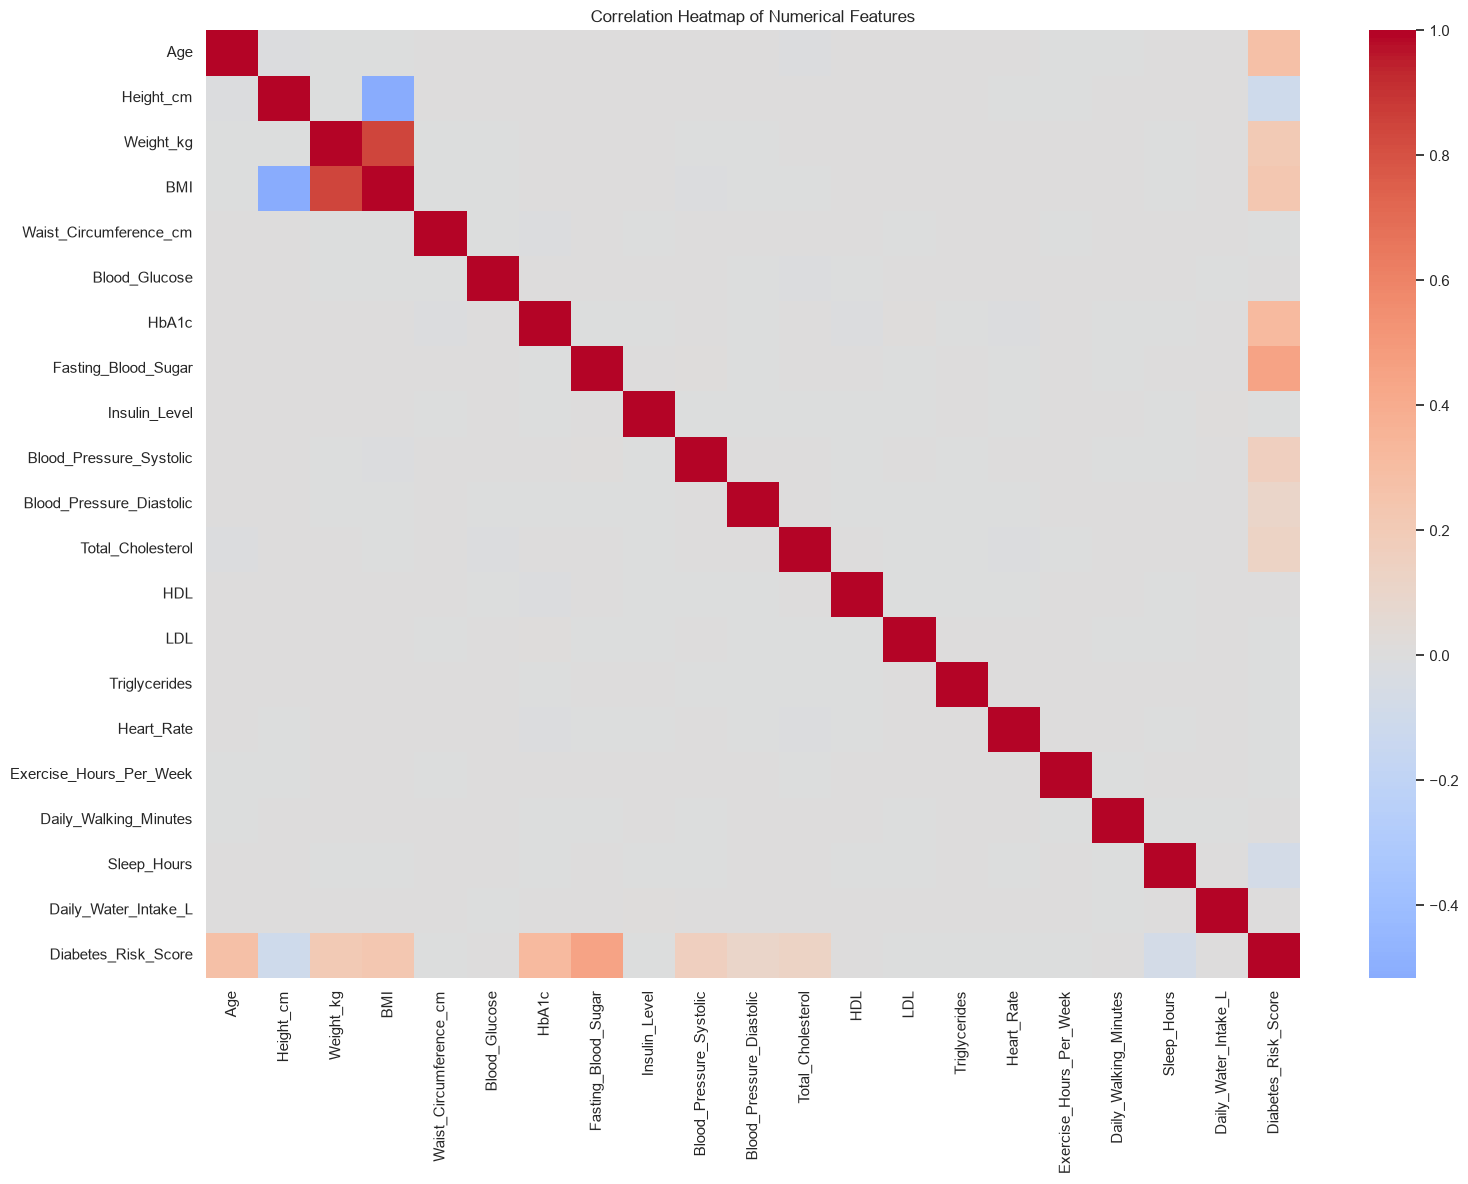

In [23]:
# Correlation heatmap

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### A3. Correlation Heatmap — Observation

The heatmap shows that most numerical features have relatively weak correlations with each other. Stronger positive relationships are observed between `Height_cm`–`Weight_kg`, `Weight_kg`–`BMI`, and `BMI`–`Waist_Circumference_cm`, indicating some related measurements among the health and body-composition features.

## A2. Feature-Target Relationships

Scatter plots are used to examine the relationship between selected numerical features and the diabetes risk classes.

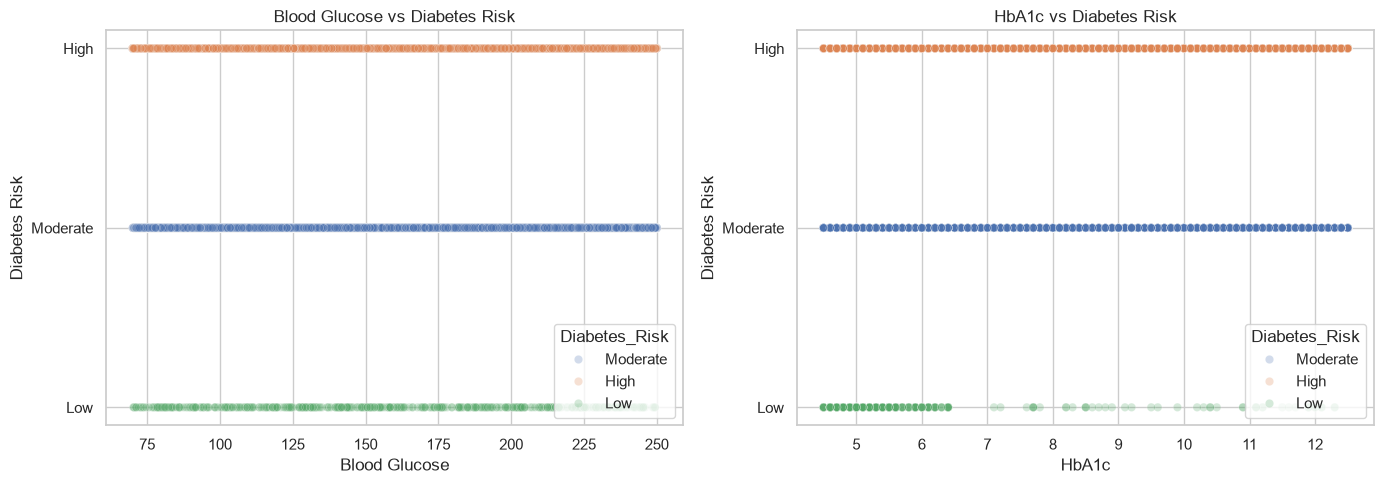

In [24]:
# Scatter plots: numerical features vs diabetes risk

risk_order = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

df["Diabetes_Risk_Code"] = df[TARGET].map(risk_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Blood Glucose vs Diabetes Risk
sns.scatterplot(
    data=df,
    x="Blood_Glucose",
    y="Diabetes_Risk_Code",
    hue=TARGET,
    alpha=0.25,
    ax=axes[0]
)

axes[0].set_title("Blood Glucose vs Diabetes Risk")
axes[0].set_xlabel("Blood Glucose")
axes[0].set_ylabel("Diabetes Risk")
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(["Low", "Moderate", "High"])

# HbA1c vs Diabetes Risk
sns.scatterplot(
    data=df,
    x="HbA1c",
    y="Diabetes_Risk_Code",
    hue=TARGET,
    alpha=0.25,
    ax=axes[1]
)

axes[1].set_title("HbA1c vs Diabetes Risk")
axes[1].set_xlabel("HbA1c")
axes[1].set_ylabel("Diabetes Risk")
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(["Low", "Moderate", "High"])

plt.tight_layout()
plt.show()


### A3. Feature-Target Relationship — Observation

The scatter plots show considerable overlap between the diabetes-risk classes for both `Blood_Glucose` and `HbA1c`. Although the features vary across the risk levels, neither plot shows a clear separation of the classes based on a single feature alone.

# B. Data Preprocessing

## B1. Data Cleaning

Missing values, duplicate records, and potential outliers are checked before model training.

In [25]:
# Check missing values and duplicates

print("Missing values:")
display(df.isnull().sum().to_frame("Missing Count"))

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:


,Missing Count
Patient_ID,0
Age,497
Gender,0
Country,0
Height_cm,2945
Weight_kg,2962
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,959
HbA1c,1974



Duplicate rows: 0


In [26]:
# Handle missing values

for col in numerical_features:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing values after treatment:", df.isnull().sum().sum())

Total missing values after treatment: 0


In [27]:
# Check for outliers using the IQR method

outlier_summary = {}

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_summary[col] = (
        ((df[col] < lower) | (df[col] > upper)).sum()
    )

outlier_summary = pd.Series(outlier_summary).sort_values(ascending=False)

display(
    outlier_summary.to_frame("Outlier Count")
)

,Outlier Count
Diabetes_Risk_Score,237
BMI,28
Age,0
Weight_kg,0
Height_cm,0
Waist_Circumference_cm,0
Blood_Glucose,0
Fasting_Blood_Sugar,0
HbA1c,0
Blood_Pressure_Systolic,0


In [28]:
# Treat detected outliers using IQR capping

outlier_features = ["Diabetes_Risk_Score", "BMI"]

for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers capped for:", outlier_features)

Outliers capped for: ['Diabetes_Risk_Score', 'BMI']


## B3. Feature Engineering

A new `Pulse_Pressure` feature is created from systolic and diastolic blood pressure. This feature represents the difference between the two blood-pressure measurements and may provide additional information for classification.

## B2. Feature Preparation and Train-Test Split

The data is divided into training and testing sets using stratified sampling. Numerical features are scaled and categorical features are encoded using preprocessing fitted only on the training data.

In [32]:
# Create an engineered feature

df["Pulse_Pressure"] = (
    df["Blood_Pressure_Systolic"]
    - df["Blood_Pressure_Diastolic"]
)

print("Feature engineered successfully.")

display(
    df[
        [
            "Blood_Pressure_Systolic",
            "Blood_Pressure_Diastolic",
            "Pulse_Pressure"
        ]
    ].head()
)

Feature engineered successfully.


,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Pulse_Pressure
0,94,61,33
1,148,100,48
2,101,108,-7
3,120,63,57
4,190,90,100


### B3. Feature Engineering — Observation

The `Pulse_Pressure` feature was successfully created from systolic and diastolic blood pressure. It provides an additional representation of blood-pressure variation for the classification models.

## B2. Feature Preparation and Train-Test Split

The data is divided into training and testing sets using stratified sampling. Numerical features are scaled and categorical features are encoded using preprocessing fitted only on the training data.

In [29]:
# Separate features and target

X = df.drop(
    columns=[TARGET, "Patient_ID", "Diabetes_Risk_Code"]
)

y = df[TARGET]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (50000, 40)
Target shape: (50000,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=GLOBAL_SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (40000, 40)
Testing set : (10000, 40)


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Separate numerical and categorical columns
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Numerical preprocessing
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

C:\Users\HP\AppData\Local\Temp\ipykernel_21824\1034559668.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(


Processed training shape: (40000, 108)
Processed testing shape : (10000, 108)


### B2. Feature Preparation — Observation

The dataset was successfully divided into training and testing sets using stratified sampling. Numerical features were scaled and categorical features were encoded using preprocessing fitted only on the training data.